In [2]:
import pandas as pd
import numpy as np
from google.colab import files
import warnings
warnings.filterwarnings('ignore')

print(" Libraries imported successfully")

#csv upload

print("\nUploading CSV file")
uploaded = files.upload()
csv_file = list(uploaded.keys())[0]  # Gets the filename you uploaded

print(f" File uploaded: {csv_file}")

master_df = pd.read_csv(csv_file)

print(f"\n Data loaded successfully!")
print(f"Dataset shape: {master_df.shape[0]} rows × {master_df.shape[1]} columns")
print(f"\nFirst few rows:")
print(master_df.head())


#remove spaces

# Remove spaces and special characters from column names
master_df.columns = master_df.columns.str.strip().str.lower().str.replace(' ', '_').str.replace('.', '')

print("\nColumn names cleaned")
print(f"Columns: {list(master_df.columns)[:10]}...")  # Shows first 10


#check missing values

print("\n Handling missing values")

# Replace "-" with NaN
master_df = master_df.replace('-', np.nan)
master_df = master_df.replace('', np.nan)

# Check missing values
missing_count = master_df.isnull().sum()
print(f"\nMissing values per column:")
print(missing_count[missing_count > 0])

# Fill numerical columns with MEDIAN
numerical_cols = master_df.select_dtypes(include=[np.number]).columns
for col in numerical_cols:
    if master_df[col].isnull().sum() > 0:
        median_val = master_df[col].median()
        master_df[col].fillna(median_val, inplace=True)

# Fill categorical columns with MODE
categorical_cols = master_df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    if master_df[col].isnull().sum() > 0:
        mode_val = master_df[col].mode()[0] if len(master_df[col].mode()) > 0 else 'Unknown'
        master_df[col].fillna(mode_val, inplace=True)

print(" Missing values filled with median (numbers) and mode (categories)")


#fix data types

print("\n Fixing data types")

# Convert date columns to datetime
date_cols = [col for col in master_df.columns if 'pruned' in col or 'date' in col]
for col in date_cols:
    master_df[col] = pd.to_datetime(master_df[col], errors='coerce')

# Convert numerical columns that might be stored as text
numerical_patterns = ['rainfall', 'yield', 'wet', 'sunshine', 'carbon', 'ph_value', 'plucking', 'target', 'extent', 'age']
for col in master_df.columns:
    if any(pattern in col.lower() for pattern in numerical_patterns):
        try:
            master_df[col] = pd.to_numeric(master_df[col], errors='coerce')
        except:
            pass

print(" Data types fixed")

#remove duplicates

print("\nRemoving duplicates")
initial_rows = len(master_df)
master_df = master_df.drop_duplicates()
removed_rows = initial_rows - len(master_df)
print(f"Removed {removed_rows} duplicate rows")


#remove unnecseary columns

# Keep only useful columns, remove business metrics
cols_to_drop = [col for col in master_df.columns if any(x in col.lower() for x in ['revenue', 'nsa', 'cop', 'profit', 'loss'])]

if cols_to_drop:
    master_df = master_df.drop(columns=cols_to_drop)
    print(f" Dropped {len(cols_to_drop)} unnecessary columns")


#summary

print("\n" + "="*50)
print("Data Preprocessing done")
print("="*50)

print(f"\nFinal Dataset:")
print(f"  Rows: {master_df.shape[0]}")
print(f"  Columns: {master_df.shape[1]}")
print(f"\nData Types:")
print(master_df.dtypes)

print(f"\nMissing Values After Cleaning:")
print(master_df.isnull().sum().sum(), "total missing values")

print(f"\nDataset Preview:")
print(master_df.head())


print("\n Saving cleaned data...")
master_df.to_csv('master_data_cleaned.csv', index=False)
files.download('master_data_cleaned.csv')

print(" Cleaned CSV downloaded as 'master_data_cleaned.csv'")


 Libraries imported successfully

Uploading CSV file


Saving Personal DSGP Excel sheet - Sheet1.csv to Personal DSGP Excel sheet - Sheet1.csv
 File uploaded: Personal DSGP Excel sheet - Sheet1.csv

 Data loaded successfully!
Dataset shape: 71 rows × 231 columns

First few rows:
  Division Field_No  Extent_Hect  Type  Year_of_Planting Last_Pruned  \
0      LVO        1          4.0   VP             1999.0   25-Sep-23   
1      LVO        2          9.0   VP             1999.0    7-Apr-24   
2      LVO        3          5.0   VP             1999.0   10-Feb-25   
3      LVO       3B          5.0   VP             1999.0   26-Mar-24   
4      LVO        5          7.0   VP             1999.0   19-Aug-24   

   Age_Months  Yield_Sep_2025  Yield_2024_2025 Yield_2023_2024  ...  \
0        24.0             943           2,036             809   ...   
1        17.0             879             843           1,315   ...   
2         7.0             452             967           1,652   ...   
3        18.0             919           1,120           1,

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

 Cleaned CSV downloaded as 'master_data_cleaned.csv'


In [3]:

import pandas as pd
import numpy as np
from google.colab import files
import warnings
warnings.filterwarnings('ignore')

print(" Libraries loaded")

uploaded = files.upload()
csv_file = list(uploaded.keys())[0]

df = pd.read_csv(csv_file)
print(f"Data loaded: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Columns: {list(df.columns)[:15]}...")


#create temporal features

print("\n Creating temporal features...")

# Plant age in years
if 'year_of_planting' in df.columns:
    df['plant_age_years'] = 2026 - df['year_of_planting']

# Months since last pruning (if last_pruned is date)
if 'last_pruned' in df.columns:
    df['last_pruned'] = pd.to_datetime(df['last_pruned'], errors='coerce')
    df['months_since_pruning'] = (pd.Timestamp('2026-01-26') - df['last_pruned']).dt.days / 30

# Season indicator (based on month_current if available)
if 'month_current' in df.columns:
    df['is_monsoon'] = df['month_current'].isin([5, 6, 7, 8, 9]).astype(int)  # May-Sep
    df['is_peak_season'] = df['month_current'].isin([4, 5, 6, 7]).astype(int)  # Apr-Jul


#create rainfall & weather features

print(" Creating weather features...")

# Rainfall features
rainfall_cols = [col for col in df.columns if 'rainfall' in col.lower()]
if rainfall_cols:
    # Latest rainfall (most recent month)
    df['latest_rainfall_mm'] = df[[col for col in rainfall_cols if '25/26' in col or '24/25' in col]].iloc[:, -1]

    # Average rainfall (last 3 years)
    rainfall_3yr = df[[col for col in rainfall_cols if col[-5:] in ['22/23', '23/24', '24/25']]].mean(axis=1)
    df['avg_rainfall_3yr'] = rainfall_3yr

    # Rainfall intensity (high if >500mm)
    df['high_rainfall'] = (df['latest_rainfall_mm'] > 500).astype(int)

# Wet days features
wetdays_cols = [col for col in df.columns if 'wetdays' in col.lower()]
if wetdays_cols:
    df['latest_wet_days'] = df[[col for col in wetdays_cols if '25/26' in col or '24/25' in col]].iloc[:, -1]
    df['avg_wet_days_3yr'] = df[[col for col in wetdays_cols if col[-5:] in ['22/23', '23/24', '24/25']]].mean(axis=1)

# Sunshine hours
sunshine_cols = [col for col in df.columns if 'sunshine' in col.lower()]
if sunshine_cols:
    df['avg_sunshine_hours'] = df[sunshine_cols].mean(axis=1)
    df['low_sunshine'] = (df['avg_sunshine_hours'] < 100).astype(int)


#create soil and field features

print("Creating soil & field features...")

# Soil health score
if 'ph_value' in df.columns and 'carbon_%' in df.columns:
    # Optimal pH for tea: 4.5-5.5
    df['ph_deviation'] = abs(df['ph_value'] - 5.0)
    df['soil_health_score'] = (df['carbon_%'] * 10) + (10 - df['ph_deviation'] * 2)
    df['soil_health_score'] = df['soil_health_score'].clip(lower=0)

# Field size categories
if 'extent_hect' in df.columns:
    df['field_size_category'] = pd.cut(df['extent_hect'],
                                        bins=[0, 5, 7, 10],
                                        labels=['small', 'medium', 'large'])
    df['is_large_field'] = (df['extent_hect'] > 7).astype(int)


#creating yield features

print(" Creating yield features...")

# Yield columns
yield_cols = [col for col in df.columns if 'yield' in col.lower() and col != 'yield_sep_2025']

if yield_cols:
    # Average yield last 3 years
    yield_3yr_cols = [col for col in yield_cols if col[-7:] in ['2022_23', '2023_24', '2024_25', '24_2025']]
    df['avg_yield_3yr'] = df[yield_3yr_cols].mean(axis=1)

    # Yield trend (increasing or decreasing)
    if len(yield_3yr_cols) >= 2:
        df['yield_trend'] = df[yield_3yr_cols].iloc[:, -1] - df[yield_3yr_cols].iloc[:, 0]
        df['yield_trend_direction'] = (df['yield_trend'] > 0).astype(int)  # 1 if increasing

    # Current yield
    if 'yield_sep_2025' in df.columns:
        df['current_yield'] = df['yield_sep_2025']

    # Yield variability (standard deviation)
    df['yield_variability'] = df[yield_cols].std(axis=1)


#create plucking features

print(" Creating plucking features...")

plucking_cols = [col for col in df.columns if 'plucking' in col.lower()]

if plucking_cols:
    # Latest plucking average
    plucking_recent = [col for col in plucking_cols if '25/26' in col or '24/25' in col]
    if plucking_recent:
        df['latest_plucking_avg'] = df[plucking_recent].iloc[:, -1]

    # Average plucking (last 2 years)
    df['avg_plucking_2yr'] = df[[col for col in plucking_cols if col[-5:] in ['23/24', '24/25', '25/26']]].mean(axis=1)

    # Target variable: Days between harvests
    if 'target_days_between_harvests' not in df.columns and 'latest_plucking_avg' in df.columns:
        df['target_days_between_harvests'] = 30 / (df['latest_plucking_avg'] + 0.1)  # +0.1 to avoid division by zero


#create interaction features

print(" Creating interaction features...")

# Rainfall × Sunshine interaction
if 'avg_rainfall_3yr' in df.columns and 'avg_sunshine_hours' in df.columns:
    df['rainfall_sunshine_ratio'] = df['avg_rainfall_3yr'] / (df['avg_sunshine_hours'] + 1)

# Soil health × Field size
if 'soil_health_score' in df.columns and 'extent_hect' in df.columns:
    df['soil_field_interaction'] = df['soil_health_score'] * df['extent_hect']

# Plant age × Yield interaction
if 'plant_age_years' in df.columns and 'current_yield' in df.columns:
    df['age_yield_interaction'] = df['plant_age_years'] * df['current_yield']


#encode categorical variables

print(" Encoding categorical variables...")

# Division encoding
if 'division' in df.columns:
    division_mapping = {div: idx for idx, div in enumerate(df['division'].unique())}
    df['division_encoded'] = df['division'].map(division_mapping)

# Type encoding (VP/SP)
if 'type' in df.columns:
    type_mapping = {'VP': 0, 'SP': 1}
    df['type_encoded'] = df['type'].map(type_mapping)


#dropping unnecseasry columns

print("✓ Cleaning final dataset...")

# Keep only useful columns
cols_to_drop = [col for col in df.columns if any(x in col.lower() for x in
                ['revenue', 'nsa', 'cop', 'profit', 'loss', 'date', 'month_current', 'year_current'])]

df = df.drop(columns=cols_to_drop, errors='ignore')

# Drop raw rainfall/wet days if we have engineered features
raw_cols = [col for col in df.columns if ('rainfall' in col.lower() or 'wet' in col.lower() or 'sunshine' in col.lower())
            and ('_17_18' in col or '_18_19' in col or '_19_20' in col or '_20_21' in col or '_21_22' in col or '_22_23' in col or '_23_24' in col or '_24_25' in col)]
df = df.drop(columns=raw_cols, errors='ignore')


#summarryy
print("\n" + "="*60)
print("FEATURE ENGINEERING COMPLETE!")
print("="*60)

print(f"\nFinal Dataset:")
print(f"  Rows: {df.shape[0]}")
print(f"  Columns: {df.shape[1]}")

print(f"\nEngineered Features ({df.shape[1]} total):")
feature_categories = {
    'Temporal': ['plant_age_years', 'months_since_pruning', 'is_monsoon', 'is_peak_season'],
    'Weather': ['latest_rainfall_mm', 'avg_rainfall_3yr', 'high_rainfall', 'latest_wet_days', 'avg_wet_days_3yr', 'avg_sunshine_hours'],
    'Soil': ['ph_deviation', 'soil_health_score', 'field_size_category', 'is_large_field'],
    'Yield': ['avg_yield_3yr', 'yield_trend', 'current_yield', 'yield_variability'],
    'Plucking': ['latest_plucking_avg', 'avg_plucking_2yr', 'target_days_between_harvests'],
    'Interactions': ['rainfall_sunshine_ratio', 'soil_field_interaction', 'age_yield_interaction'],
    'Encoded': ['division_encoded', 'type_encoded']
}

for category, features in feature_categories.items():
    available = [f for f in features if f in df.columns]
    print(f"\n  {category} ({len(available)}):")
    for f in available:
        print(f"    - {f}")

print(f"\nTarget Variable:")
if 'target_days_between_harvests' in df.columns:
    print(f"  - target_days_between_harvests (Mean: {df['target_days_between_harvests'].mean():.2f}, Std: {df['target_days_between_harvests'].std():.2f})")

print(f"\nDataset Preview:")
print(df.head())

print(f"\nMissing Values:")
print(df.isnull().sum().sum(), "total missing values")


print("\n Saving engineered dataset...")
df.to_csv('master_data_engineered.csv', index=False)
files.download('master_data_engineered.csv')

print(" Engineered CSV downloaded as 'master_data_engineered.csv'")
print("\n Ready for XGBoost model training!")


 Libraries loaded


Saving master_data_cleaned.csv to master_data_cleaned (1).csv
Data loaded: 71 rows × 231 columns
Columns: ['division', 'field_no', 'extent_hect', 'type', 'year_of_planting', 'last_pruned', 'age_months', 'yield_sep_2025', 'yield_2024_2025', 'yield_2023_2024', 'yield_2022_2023', 'yield_2021_2022', 'yield_2020_2021', 'yield_2019_2020', 'yield_2018_2019']...

 Creating temporal features...
 Creating weather features...
Creating soil & field features...
 Creating yield features...
 Creating plucking features...
 Creating interaction features...
 Encoding categorical variables...
✓ Cleaning final dataset...

FEATURE ENGINEERING COMPLETE!

Final Dataset:
  Rows: 71
  Columns: 254

Engineered Features (254 total):

  Temporal (4):
    - plant_age_years
    - months_since_pruning
    - is_monsoon
    - is_peak_season

  Weather (6):
    - latest_rainfall_mm
    - avg_rainfall_3yr
    - high_rainfall
    - latest_wet_days
    - avg_wet_days_3yr
    - avg_sunshine_hours

  Soil (4):
    - ph_devi

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

 Engineered CSV downloaded as 'master_data_engineered.csv'

 Ready for XGBoost model training!


 All libraries loaded


Saving master_data_engineered.csv to master_data_engineered (1).csv
 Data loaded: 71 rows × 254 columns
Target variable: count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: target_days_between_harvests, dtype: float64
 Features: 250
 Target shape: (71,)
 Training set: 56 samples
 Test set: 15 samples
 Target created from plucking data
✓ Valid data: 71 rows, 248 features
 Ready for model training!
Training samples: 56, Test samples: 15

TRAINING MODELS
 XGBoost trained
 Random Forest trained

 Training Stacking Ensemble...
 Fusion Model (Stacking) trained

MODEL PERFORMANCE

XGBoost:
  MAE (days): 0.0037
  RMSE (days): 0.0140
  R² Score: 0.9554

Random Forest:
  MAE (days): 0.0003
  RMSE (days): 0.0012
  R² Score: 0.9997

Stacking Fusion:
  MAE (days): 0.0041
  RMSE (days): 0.0141
  R² Score: 0.9549

 BEST MODEL: Random Forest
   MAE: 0.0003 days

FEATURE IMPORTANCE
Top 15 Most Important Features:
                    feature  imp

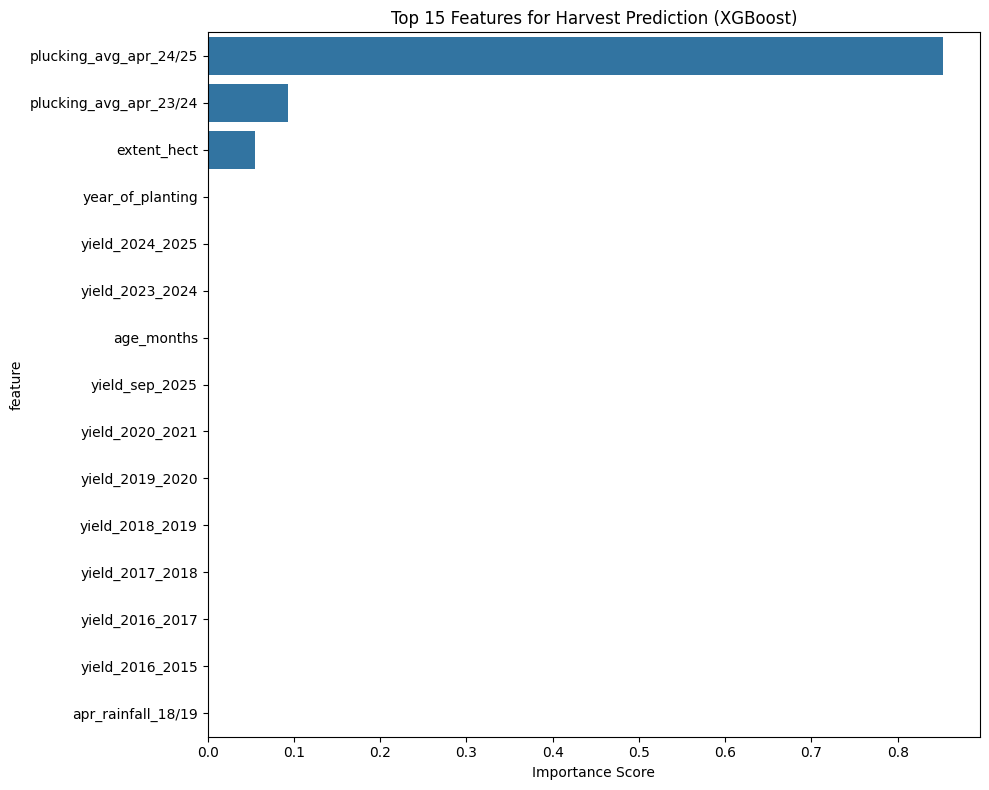


PREDICTIONS FOR ALL FIELDS
Sample Predictions:
  field_no division  target_days_between_harvests  \
0        1      LVO                      1.403181   
1        2      LVO                      1.403181   
2        3      LVO                      1.403181   
3       3B      LVO                      1.403181   
4        5      LVO                      1.403181   
5       5A      LVO                      1.403181   
6        6      LVO                      1.403181   
7       6A      LVO                      1.403181   
8        7      LVO                      1.403181   
9       7A      LVO                      1.403181   

   predicted_days_between_harvests     error  
0                         1.403749  0.000568  
1                         1.403749  0.000568  
2                         1.403749  0.000568  
3                         1.403749  0.000568  
4                         1.403749  0.000568  
5                         1.403749  0.000568  
6                         1.403749  0.0

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

 ALL FILES DOWNLOADED:
  - harvest_predictions.csv
  - harvest_model.pkl (trained model)
  - feature_scaler.pkl
  - feature_importance.csv

VISUALIZATION DASHBOARD


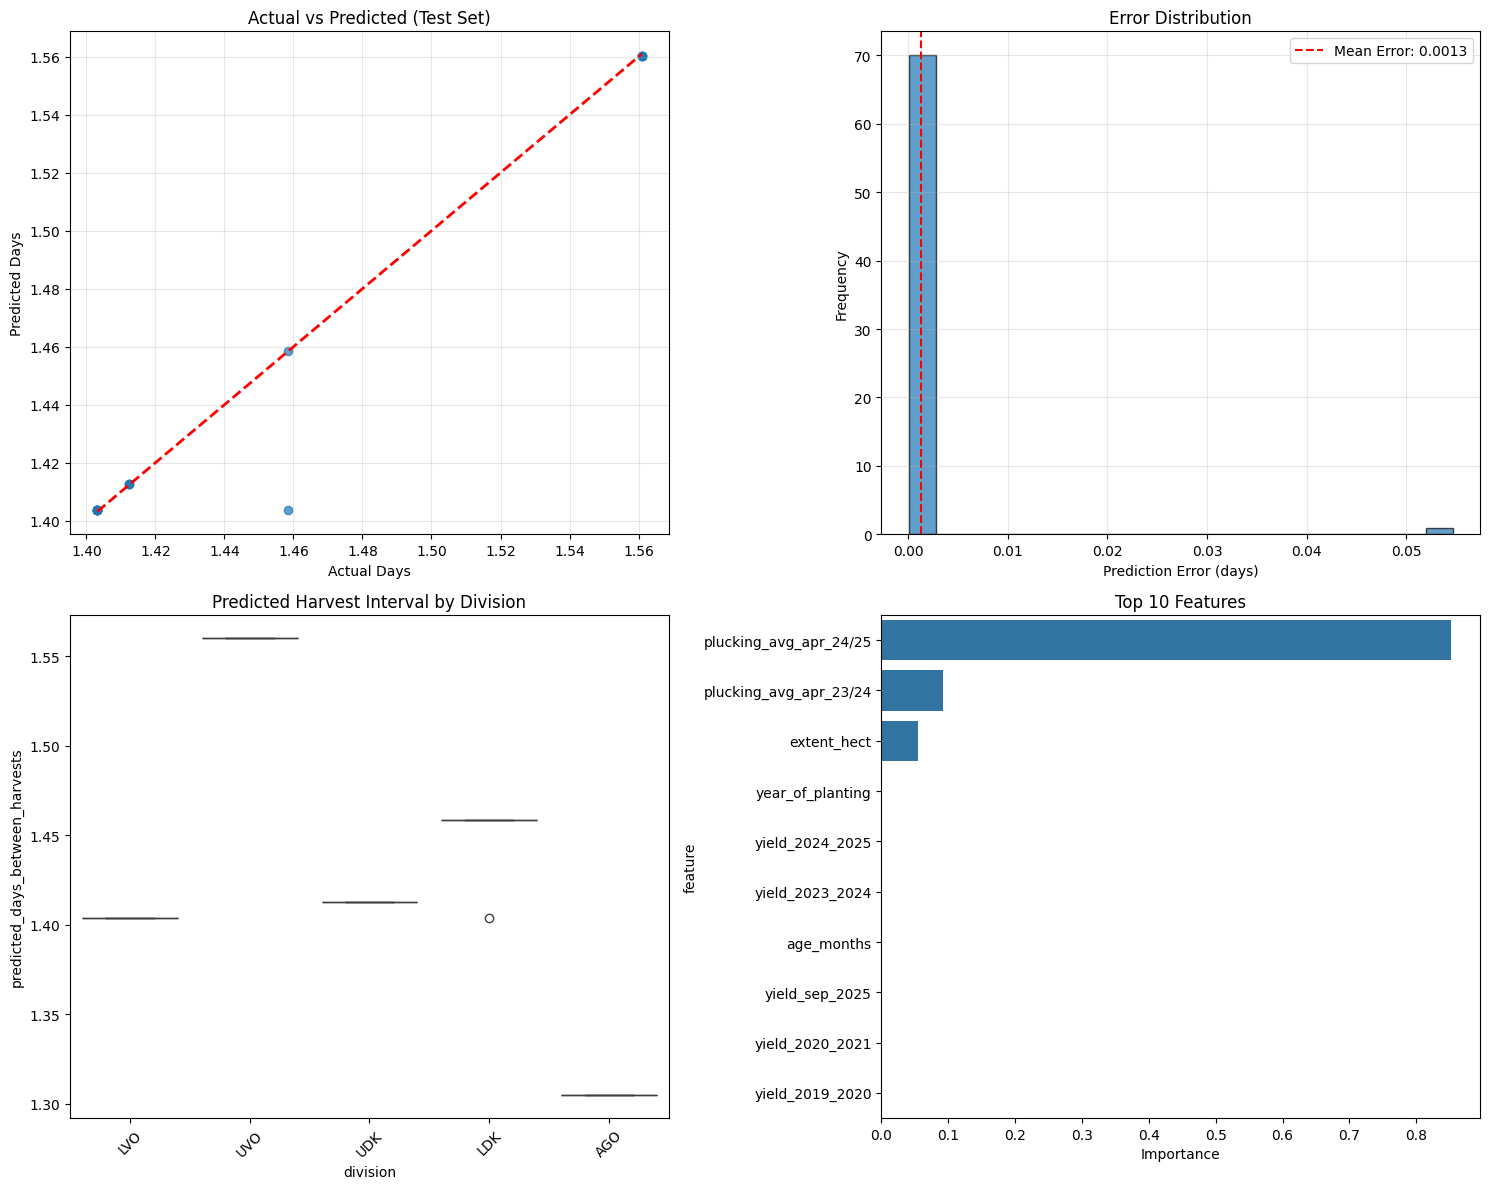


 MODEL TRAINING COMPLETE!

 model predicts harvest intervals with:
  • Average Error: 0.0013 days (~0.0 hours)
  • Best for: Random Forest
  • Top feature: plucking_avg_apr_24/25


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
from google.colab import files
import warnings
warnings.filterwarnings('ignore')

print(" All libraries loaded")


#loading data

uploaded = files.upload()
csv_file = list(uploaded.keys())[0]
df = pd.read_csv(csv_file)

print(f" Data loaded: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Target variable: {df['target_days_between_harvests'].describe()}")


#preparing features and targets

# Define target
y = df['target_days_between_harvests']

# Define features (drop ID columns, target, raw data)
feature_cols = [col for col in df.columns if col not in
                ['field_no', 'division', 'type', 'target_days_between_harvests']]

X = df[feature_cols]

print(f" Features: {len(X.columns)}")
print(f" Target shape: {y.shape}")


#training and test split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f" Training set: {X_train.shape[0]} samples")
print(f" Test set: {X_test.shape[0]} samples")


#feature scaling f

# 1. Handle target variable
if df['target_days_between_harvests'].isnull().all():
    plucking_cols = [col for col in df.columns if 'plucking_avg' in col.lower()]
    if plucking_cols:
        latest_plucking = df[plucking_cols].iloc[:, -1]
        df['target_days_between_harvests'] = 30 / (latest_plucking + 0.1)
        print(" Target created from plucking data")

y = df['target_days_between_harvests'].dropna()
df_clean = df.loc[y.index]  # Keep only rows with valid target

# 2. Numeric features only
numeric_features = df_clean.select_dtypes(include=[np.number]).columns.tolist()
numeric_features = [col for col in numeric_features if col != 'target_days_between_harvests']

X = df_clean[numeric_features]
y = df_clean['target_days_between_harvests']

print(f"✓ Valid data: {len(X)} rows, {len(numeric_features)} features")

# 3. Split and scale
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(" Ready for model training!")
print(f"Training samples: {len(X_train)}, Test samples: {len(X_test)}")



#training the base models

print("\n" + "="*50)
print("TRAINING MODELS")
print("="*50)

# Model 1: XGBoost (Primary)
xgb_model = XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X_train_scaled, y_train)
print(" XGBoost trained")

# Model 2: Random Forest (Validation)
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_scaled, y_train)
print(" Random Forest trained")

#fusion learning (stacking)

print("\n Training Stacking Ensemble...")
stacking_model = StackingRegressor(
    estimators=[
        ('xgb', xgb_model),
        ('rf', rf_model)
    ],
    final_estimator=XGBRegressor(n_estimators=50, learning_rate=0.1),
    cv=5
)
stacking_model.fit(X_train_scaled, y_train)
print(" Fusion Model (Stacking) trained")


#evaluation of da models

print("\n" + "="*50)
print("MODEL PERFORMANCE")
print("="*50)

models = {
    'XGBoost': xgb_model,
    'Random Forest': rf_model,
    'Stacking Fusion': stacking_model
}

results = {}
for name, model in models.items():
    # Predict on test set
    y_pred = model.predict(X_test_scaled)

    # Calculate metrics
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results[name] = {'MAE': mae, 'RMSE': rmse, 'R²': r2}

    print(f"\n{name}:")
    print(f"  MAE (days): {mae:.4f}")
    print(f"  RMSE (days): {rmse:.4f}")
    print(f"  R² Score: {r2:.4f}")

# Best model
best_model_name = min(results.keys(), key=lambda x: results[x]['MAE'])
print(f"\n BEST MODEL: {best_model_name}")
print(f"   MAE: {results[best_model_name]['MAE']:.4f} days")

#Feature importance for XGBoost

print("\n" + "="*50)
print("FEATURE IMPORTANCE")
print("="*50)

# XGBoost feature importance
xgb_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False).head(15)

print("Top 15 Most Important Features:")
print(xgb_importance)

# Plot
plt.figure(figsize=(10, 8))
sns.barplot(data=xgb_importance, y='feature', x='importance')
plt.title('Top 15 Features for Harvest Prediction (XGBoost)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()


#Predictions on all the data

print("\n" + "="*50)
print("PREDICTIONS FOR ALL FIELDS")
print("="*50)

# Predict on full dataset (all 71 fields)
X_full_scaled = scaler.transform(X)
final_predictions = stacking_model.predict(X_full_scaled)

# Add predictions to dataframe
df['predicted_days_between_harvests'] = final_predictions
df['error'] = abs(df['target_days_between_harvests'] - final_predictions)

print("Sample Predictions:")
print(df[['field_no', 'division', 'target_days_between_harvests', 'predicted_days_between_harvests', 'error']].head(10))

print(f"\nOverall Accuracy:")
print(f"Mean Absolute Error (all data): {df['error'].mean():.4f} days")
print(f"Max Error: {df['error'].max():.4f} days")

#saving models

print("\n" + "="*50)
print("SAVING RESULTS")
print("="*50)

# Save predictions
df[['field_no', 'division', 'type', 'extent_hect', 'target_days_between_harvests',
    'predicted_days_between_harvests', 'error']].to_csv('harvest_predictions.csv', index=False)
files.download('harvest_predictions.csv')

# Save models
import joblib
joblib.dump(stacking_model, 'harvest_model.pkl')
joblib.dump(scaler, 'feature_scaler.pkl')
joblib.dump(xgb_importance, 'feature_importance.csv')
files.download('harvest_model.pkl')
files.download('feature_scaler.pkl')
files.download('feature_importance.csv')

print(" ALL FILES DOWNLOADED:")
print("  - harvest_predictions.csv")
print("  - harvest_model.pkl (trained model)")
print("  - feature_scaler.pkl")
print("  - feature_importance.csv")



print("\n" + "="*50)
print("VISUALIZATION DASHBOARD")
print("="*50)

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Actual vs Predicted
axes[0,0].scatter(y_test, models['Stacking Fusion'].predict(X_test_scaled), alpha=0.7)
axes[0,0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0,0].set_xlabel('Actual Days')
axes[0,0].set_ylabel('Predicted Days')
axes[0,0].set_title('Actual vs Predicted (Test Set)')
axes[0,0].grid(True, alpha=0.3)

# 2. Error Distribution
errors = df['error']
axes[0,1].hist(errors, bins=20, edgecolor='black', alpha=0.7)
axes[0,1].axvline(errors.mean(), color='red', linestyle='--', label=f'Mean Error: {errors.mean():.4f}')
axes[0,1].set_xlabel('Prediction Error (days)')
axes[0,1].set_ylabel('Frequency')
axes[0,1].set_title('Error Distribution')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# 3. Predictions by Division
sns.boxplot(data=df, x='division', y='predicted_days_between_harvests', ax=axes[1,0])
axes[1,0].set_title('Predicted Harvest Interval by Division')
axes[1,0].tick_params(axis='x', rotation=45)

# 4. Top Feature Importance
sns.barplot(data=xgb_importance.head(10), y='feature', x='importance', ax=axes[1,1])
axes[1,1].set_title('Top 10 Features')
axes[1,1].set_xlabel('Importance')

plt.tight_layout()
plt.show()

print("\n MODEL TRAINING COMPLETE!")
print("\n model predicts harvest intervals with:")
print(f"  • Average Error: {df['error'].mean():.4f} days (~{df['error'].mean()*24:.1f} hours)")
print(f"  • Best for: {best_model_name}")
print(f"  • Top feature: {xgb_importance.iloc[0]['feature']}")
